In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from IPython.display import display, Image

In [ ]:
import pandas as pd
df=pd.read_csv(r"C:\\Users\\New folder\\labels.csv")
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10222 entries, 0 to 10221
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10222 non-null  object
 1   breed   10222 non-null  object
dtypes: object(2)
memory usage: 159.8+ KB


id       0
breed    0
dtype: int64

In [14]:
filenames = [r"C:\Users\New folder\train\\" + fname + ".jpg" for fname in df["id"]]
filenames[:10]

['C:\\Users\\New folder\\train\\\\000bec180eb18c7604dcecc8fe0dba07.jpg',
 'C:\\Users\\New folder\\train\\\\001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'C:\\Users\\New folder\\train\\\\001cdf01b096e06d78e9e5112d419397.jpg',
 'C:\\Users\\New folder\\train\\\\00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'C:\\Users\\New folder\\train\\\\0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'C:\\Users\\New folder\\train\\\\002211c81b498ef88e1b40b9abf84e1d.jpg',
 'C:\\Users\\New folder\\train\\\\00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'C:\\Users\\New folder\\train\\\\002a283a315af96eaea0e28e7163b21b.jpg',
 'C:\\Users\\New folder\\train\\\\003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'C:\\Users\\New folder\\train\\\\0042188c895a2f14ef64a918ed9c7b64.jpg']

In [18]:
import os
if len(os.listdir(r"C:\Users\New folder\train\\")) == len(filenames):
  print("Filenames match actual amount of files!")
else:
  print("Filenames do not match actual amount of files, check the target directory.")

Filenames match actual amount of files!


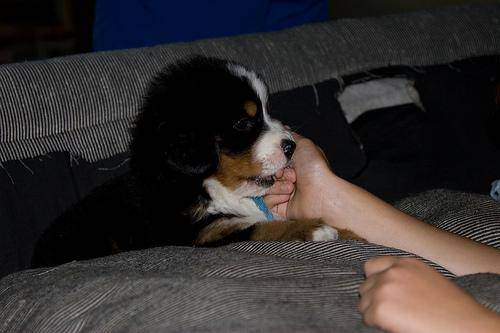

In [30]:
Image(filenames[9900])

In [31]:
df["id"]=df["id"]+".jpg"

In [32]:
train_df,Val_df = train_test_split(df, test_size=0.2, random_state=42)

In [33]:
IMG_SIZE = 128
batch_size = 32
train_gen=ImageDataGenerator(rescale=1./255)
val_gen=ImageDataGenerator(rescale=1./255)
train_data=train_gen.flow_from_dataframe(train_df, directory=r"C:\Users\New folder\train\\", x_col="id", y_col="breed", target_size=(IMG_SIZE, IMG_SIZE), batch_size=batch_size, class_mode="categorical")
val_data=val_gen.flow_from_dataframe(Val_df, directory=r"C:\Users\New folder\train\\", x_col="id", y_col="breed", target_size=(IMG_SIZE, IMG_SIZE), batch_size=batch_size, class_mode="categorical")

Found 8177 validated image filenames belonging to 120 classes.
Found 2045 validated image filenames belonging to 120 classes.


In [42]:
num_classes = len(train_data.class_indices)
print("Number of classes:", num_classes)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    layers.Dense(num_classes, activation="softmax")
])

Number of classes: 120


c:\Users\Ali Mehdi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [45]:
model.fit(train_data, validation_data=val_data, epochs=3)

Epoch 1/3
256/256 ━━━━━━━━━━━━━━━━━━━━ 199s 767ms/step - accuracy: 0.0143 - loss: 4.7700 - val_accuracy: 0.0235 - val_loss: 4.6407
Epoch 2/3
256/256 ━━━━━━━━━━━━━━━━━━━━ 126s 494ms/step - accuracy: 0.0448 - loss: 4.4520 - val_accuracy: 0.0469 - val_loss: 4.4259
Epoch 3/3
256/256 ━━━━━━━━━━━━━━━━━━━━ 131s 512ms/step - accuracy: 0.1454 - loss: 3.7658 - val_accuracy: 0.0499 - val_loss: 4.6596


In [46]:
model.save("dog_cnn_model.h5")

In [53]:
# Load model
model = tf.keras.models.load_model("dog_cnn_model.h5")

# Class names
class_names = list(train_data.class_indices.keys())

# 🔥 USER INPUT
img_path = "D:/D/work trash/n02099601_3004.jpg"

# Load image
img = load_img(img_path, target_size=(128,128))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)

# Output
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

print("🐶 Predicted Breed:", predicted_class)
print("🔍 Confidence:", confidence)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
🐶 Predicted Breed: pomeranian
🔍 Confidence: 0.14598459
